## Set parameters

In [82]:
smoothing_size = 100
extension_factor = 1.1; 
step_size = 2;
max_width = 2048
overlap_threshold = 0.3
weight_epithelium_coverage = 0.8
weight_background_pixels = 0.2

# keep the slice and the mask in a folder called "input"
slice_file = "input\h211989 sox10_ROI_2.tif"
slice_detail = "sox10_benign_case56_match2"
mask_name = slice_detail + ".png"
mask_file = "input/" + mask_name

# the results will be written in a folder called "output"
# For the 'after improvement' code, change "before_" to "after_" in the names below
patched_slice_name = "output/patched_after_improvement_" + mask_name
metrics_file_name = "output/metrics_after_improvement_" + slice_detail + ".csv"
patch_length_filename = "output/patch_lengths_after_improvement_" + slice_detail + ".csv"

<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Patrick\AppData\Local\Temp\ipykernel_16484\165551644.py:10: SyntaxWarning: invalid escape sequence '\h'
  slice_file = "input\h211989 sox10_ROI_2.tif"


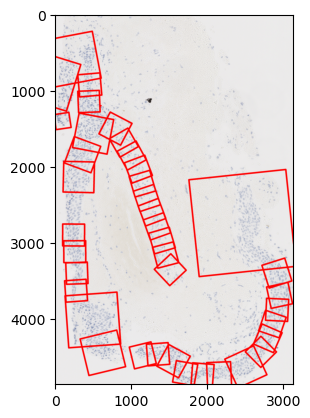

In [83]:
import numpy as np
import cv2
from shapely.geometry import Polygon
from shapely.strtree import STRtree
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from matplotlib import colors
import pandas as pd
import csv

def draw_patches(image, patch_list, color=[255,0,0], thickness=20):
    patches_on_slice = image.copy()
    for contour_patches in patch_list:
        for patch in contour_patches:
            points = patch.astype(np.int32)
            cv2.polylines(patches_on_slice, [points], isClosed=True, color=color, thickness=thickness)
    return patches_on_slice

def patch_overlap(square1, square2):
    square1, square2 = Polygon(square1), Polygon(square2)
    if not square1.intersects(square2):
        return 0
    intersection_area = square1.intersection(square2).area
    smallest_area = min(square1.area, square2.area)
    return intersection_area / smallest_area

# Reading data
tissue_slice = cv2.cvtColor(cv2.imread(slice_file), cv2.COLOR_BGR2RGB)
epithelium_mask = cv2.cvtColor(cv2.imread(mask_file), cv2.COLOR_BGR2RGB)
epithelium_mask_gray = cv2.cvtColor(epithelium_mask, cv2.COLOR_RGB2GRAY)
Otsu_threshold, epithelium_mask_2D = cv2.threshold(epithelium_mask_gray, 0, 255, 
                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Getting contours
contours, hierarchy = cv2.findContours(epithelium_mask_2D, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Getting tangents and normals on contour points
all_normals=[]
all_tangents = []

for contour in contours:
    contour_points = contour.reshape(-1,2)
    num_contour_points = len(contour_points)
    tangents = np.zeros_like(contour_points, dtype = float)

    for i in range(num_contour_points):
        prev_idx = (i - smoothing_size) % num_contour_points 
        next_idx = (i + smoothing_size) % num_contour_points 
        tangent = contour_points[next_idx] - contour_points[prev_idx]
        tangent = tangent / (np.linalg.norm(tangent) + 1e-8)
        tangents[i] = tangent            

    normals = np.zeros_like(tangents)
    normals[:,0] = -tangents[:,1]
    normals[:,1] = tangents[:,0]
    
    all_normals.append(normals)
    all_tangents.append(tangents)
    
all_patches = []
all_patch_lengths = []
height, width = epithelium_mask_2D.shape

for c in range(len(contours)):
    contour_points = contours[c].reshape(-1, 2)
    contour_normals = all_normals[c]
    contour_tangents = all_tangents[c]
    contour_patch_lengths = []
    squares = []
    
    for i, point in enumerate(contour_points):
        point = point.astype(int)
        steps = np.arange(0, max_width, step_size)[:, None]
        normal_points = np.clip(point - steps * contour_normals[i], 0, [width - 1, height - 1]).astype(int)
        pixel_values = epithelium_mask_2D[normal_points[:, 1], normal_points[:, 0]]
        stop = np.where(pixel_values == 0)[0]
        epithelium_width = stop[0] * step_size if stop.size > 0 else max_width
        patch_length = int(epithelium_width * extension_factor)
        half_patch_length = patch_length // 2 
        corners = np.array([
            point + (contour_tangents[i] * half_patch_length),
            point - (contour_tangents[i] * half_patch_length),
            point - (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length),
            point + (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length)
        ])
        squares.append(corners)
        contour_patch_lengths.append(patch_length)
    all_patches.append(squares)
    all_patch_lengths.append(contour_patch_lengths)

def filter_patches(all_patches, all_patch_lengths, overlap_threshold):
    selected_patches = []
    selected_patch_lengths = []

    for contour_patches, contour_lengths in zip(all_patches, all_patch_lengths):
        filtered_contour_patches = []
        filtered_contour_lengths = []
        
        if not contour_patches:
            continue  # Skip empty contours
        
        # Keep first patch
        filtered_contour_patches.append(contour_patches[0])
        filtered_contour_lengths.append(contour_lengths[0])

        for patch, length in zip(contour_patches[1:], contour_lengths[1:]):
            polygon = Polygon(patch)
            keep = True  # Flag to keep the patch

            for selected_patch in filtered_contour_patches:
                if patch_overlap(polygon, Polygon(selected_patch)) > overlap_threshold:
                    keep = False
                    break  # Skip adding this patch

            if keep:
                filtered_contour_patches.append(patch)
                filtered_contour_lengths.append(length)

        selected_patches.append(filtered_contour_patches)
        selected_patch_lengths.append(filtered_contour_lengths)

    return selected_patches, selected_patch_lengths


all_selected_patches, all_selected_patch_lengths = filter_patches(all_patches, all_patch_lengths, overlap_threshold)

selected_patches_on_slice = draw_patches(tissue_slice, all_selected_patches)
cv2.imwrite(patched_slice_name, cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

# Calculating performance metrics
total_epithelium_pixels = (epithelium_mask_2D > 0).sum()
patch_mask = np.zeros_like(epithelium_mask_2D, dtype=np.uint8)

#For all patches in all contours, use them to create a mask
for contour_patches in all_selected_patches:
    for patch in contour_patches:
        patch = np.array(patch,dtype = np.int32).reshape(-1, 1, 2)
        cv2.fillPoly(patch_mask, [patch], 255)

number_of_patch_mask_pixels = np.count_nonzero(patch_mask > 0)

covered_epithelium_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D > 0))
covered_background_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D == 0))

total_epithelium_coverage = (covered_epithelium_pixels / total_epithelium_pixels*100)
background_pixel_percent = (covered_background_pixels / number_of_patch_mask_pixels*100)
score = weight_epithelium_coverage*total_epithelium_coverage + weight_background_pixels*(100 - background_pixel_percent)

# Exporting performance metrics and parameter values
metrics = pd.DataFrame({'Metric':['total_epithelium_coverage', 'background_pixel_percent',
                       'score', 'smoothing_size', 'extension_factor', 'step_size',
                       'max_width', 'overlap_threshold'], 
              'Value':[total_epithelium_coverage, background_pixel_percent, score, 
                      smoothing_size, extension_factor, step_size, max_width, overlap_threshold]})

metrics.to_csv(metrics_file_name, index=False)

# Exporting patch lengths
max_length = max(len(contour_patch_lengths) for contour_patch_lengths in all_selected_patch_lengths)

padded_list = [contour_patch_lengths + [''] * (max_length - len(contour_patch_lengths)) \
               for contour_patch_lengths in all_selected_patch_lengths]

transposed_list = list(map(list, zip(*padded_list)))

with open(patch_length_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(transposed_list)

plt.imshow(selected_patches_on_slice);

In [25]:
print(f"Total Coverage: {total_epithelium_coverage:.2f}%")
print(f"Background Pixel Percentage: {background_pixel_percent:.2f}%")
print(f"Score Percentage: {score:.2f}%")

Total Coverage: 92.87%
Background Pixel Percentage: 17.89%
Score Percentage: 90.72%
